## 🎯 Employee Attrition Prediction

### 📌 Problem Statement

In large organizations operating across multiple departments and countries, determining fair and competitive employee compensation is a complex task. Salary decisions depend on multiple factors such as experience, department, job performance, work location, overtime contribution, and leave history.

The objective of this project is to build a machine learning model that predicts an employee’s salary based on professional and organizational attributes. This system can help HR teams ensure fair pay structures, budget planning, and compensation benchmarking.

###  1️⃣ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

##  2️⃣ Load Dataset

In [2]:
df=pd.read_csv("Employees.csv")
df.head()

,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
0,1,Ghadir,Hmshw,Male,04/04/2018,7,Quality Control,Egypt,West,1560,18720,3.0,1,0,183
1,2,Omar,Hishan,Male,05/21/2020,5,Quality Control,Saudi Arabia,West,3247,38964,1.0,0,5,198
2,3,Ailya,Sharaf,Female,09/28/2017,8,Major Mfg Projects,Saudi Arabia,West,2506,30072,2.0,0,3,192
3,4,Lwiy,Qbany,Male,08/14/2018,7,Manufacturing,United Arab Emirates,Main,1828,21936,3.0,0,0,7
4,5,Ahmad,Bikri,Male,03/11/2020,5,Manufacturing,Egypt,Main,970,11640,5.0,0,5,121


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No              689 non-null    int64  
 1   First Name      689 non-null    object 
 2   Last Name       689 non-null    object 
 3   Gender          689 non-null    object 
 4   Start Date      689 non-null    object 
 5   Years           689 non-null    int64  
 6   Department      689 non-null    object 
 7   Country         689 non-null    object 
 8   Center          689 non-null    object 
 9   Monthly Salary  689 non-null    int64  
 10  Annual Salary   689 non-null    int64  
 11  Job Rate        689 non-null    float64
 12  Sick Leaves     689 non-null    int64  
 13  Unpaid Leaves   689 non-null    int64  
 14  Overtime Hours  689 non-null    int64  
dtypes: float64(1), int64(7), object(7)
memory usage: 80.9+ KB


In [4]:
df.describe()

,No,Years,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
count,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000
mean,345.000000,6.592163,2068.201742,24818.420900,3.586357,1.609579,0.759071,13.702467
std,199.041453,1.249650,763.289240,9159.470878,1.350125,2.196051,1.647764,25.692049
min,1.000000,5.000000,703.000000,8436.000000,1.000000,0.000000,0.000000,0.000000
25%,173.000000,6.000000,1436.000000,17232.000000,3.000000,0.000000,0.000000,3.000000
50%,345.000000,6.000000,2077.000000,24924.000000,3.000000,0.000000,0.000000,7.000000
75%,517.000000,7.000000,2682.000000,32184.000000,5.000000,3.000000,0.000000,10.000000
max,689.000000,10.000000,3450.000000,41400.000000,5.000000,6.000000,6.000000,198.000000


##  3️⃣ Data Cleaning

In [5]:
df.isnull().sum()

No                0
First Name        0
Last Name         0
Gender            0
Start Date        0
Years             0
Department        0
Country           0
Center            0
Monthly Salary    0
Annual Salary     0
Job Rate          0
Sick Leaves       0
Unpaid Leaves     0
Overtime Hours    0
dtype: int64

In [6]:
df.drop(["No", "First Name", "Last Name", "Monthly Salary"], axis=1, inplace=True)
df.head()

,Gender,Start Date,Years,Department,Country,Center,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
0,Male,04/04/2018,7,Quality Control,Egypt,West,18720,3.0,1,0,183
1,Male,05/21/2020,5,Quality Control,Saudi Arabia,West,38964,1.0,0,5,198
2,Female,09/28/2017,8,Major Mfg Projects,Saudi Arabia,West,30072,2.0,0,3,192
3,Male,08/14/2018,7,Manufacturing,United Arab Emirates,Main,21936,3.0,0,0,7
4,Male,03/11/2020,5,Manufacturing,Egypt,Main,11640,5.0,0,5,121


## 4️⃣ Feature Engineering

In [7]:
df['Start Date']=pd.to_datetime(df['Start Date'])
current_year=pd.Timestamp.now().year

df['Experience']= current_year - df['Start Date'].dt.year

df.drop('Start Date', axis=1, inplace=True)

In [34]:
# Salary bands
df["Salary Band"] = pd.qcut(df["Annual Salary"], 3, labels=["Low", "Medium", "High"])

## 5️⃣ Exploratory Date Analysis (EDA)

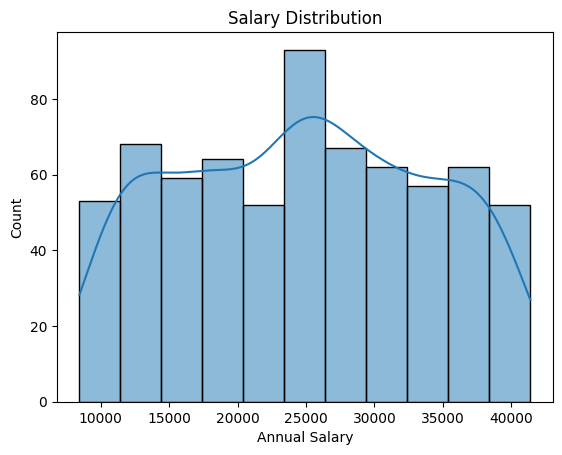

In [35]:
sns.histplot(df['Annual Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

In [37]:
df = pd.get_dummies(df, drop_first=True)

In [38]:
X = df.drop("Annual Salary", axis=1)
y = df["Annual Salary"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Years                                   689 non-null    int64  
 1   Annual Salary                           689 non-null    int64  
 2   Job Rate                                689 non-null    float64
 3   Sick Leaves                             689 non-null    int64  
 4   Unpaid Leaves                           689 non-null    int64  
 5   Overtime Hours                          689 non-null    int64  
 6   Experience                              689 non-null    int32  
 7   Gender_Male                             689 non-null    bool   
 8   Department_Creative                     689 non-null    bool   
 9   Department_Environmental Compliance     689 non-null    bool   
 10  Department_Environmental Health/Safety  689 non-null    bool  

In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [43]:
y_pred = model.predict(X_test)

In [44]:
print("R2 Score: ", r2_score(y_test,y_pred))
print("MAE : ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.8856664160130003
MAE :  2693.8138053203206


In [47]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns, "features.pkl")

['features.pkl']

## 🏭 Industry Problem

Organizations face several real-world compensation challenges:

🔹 1. Salary Standardization

Ensuring employees with similar experience and roles are compensated fairly.

🔹 2. Budget Planning

HR teams must forecast salary budgets for upcoming hiring cycles.

🔹 3. Compensation Benchmarking

Companies need data-driven salary estimation to stay competitive in the market.

🔹 4. Detecting Salary Anomalies

Identifying overpaid or underpaid employees compared to similar profiles.

Manual methods are slow, inconsistent, and not scalable.
A predictive model enables automated and objective compensation analysis.

## 🎯 How the Solution Works
### Step 1: Data Analysis

Analyze employee-level data such as:

Experience

Department

Country

Job Performance

Overtime Contribution

Leave Patterns

### Step 2: Feature Engineering

Convert raw data into meaningful indicators:

Tenure/Experience derived from start date

Performance-experience interaction

Departmental and regional encoding

### Step 3: Model Development

Train a regression model to learn salary patterns from historical data.

The model identifies key salary-driving factors and predicts expected annual salary for a given employee profile.

### Step 4: Deployment

Deploy the trained model using Streamlit to allow HR teams to:

Input employee details

Receive real-time salary predictions

Use the output for benchmarking and planning